### **Model Building**

In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, ConfusionMatrixDisplay
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [97]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [98]:
df = pd.read_csv('../data/processed/online_shoppers_intention_processed.csv')
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,Region_2,Region_3,Region_4,Region_5,Region_6,Region_7,Region_8,Region_9,Browser_2,Browser_3,Browser_4,Browser_5,Browser_6,Browser_7,Browser_8,Browser_9,Browser_10,Browser_11,Browser_12,Browser_13,OperatingSystems_2,OperatingSystems_3,OperatingSystems_4,OperatingSystems_5,OperatingSystems_6,OperatingSystems_7,OperatingSystems_8,TrafficType_2,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.000,0,0.000,6,1156.500,0.000,0.033,0.000,0.000,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,4,52.000,1,7.000,46,3087.000,0.004,0.021,16.946,0.000,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,4,106.500,0,0.000,12,806.250,0.013,0.029,0.000,0.000,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,9,497.167,0,0.000,20,1170.167,0.012,0.023,0.000,0.000,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0.000,0,0.000,3,17.000,0.000,0.033,0.000,0.000,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [99]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [101]:
pipeline = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()), 
        ('smote', SMOTE(random_state=42)), 
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scalar', StandardScaler()),
        ('SMOTE', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'XGBClassifier': Pipeline([
        ('scalar', StandardScaler()),
        ('SMOTE', SMOTE(random_state=42)),
        ('model', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ]),
    'LGBMClassifier': Pipeline([
        ('scalar', StandardScaler()),
        ('SMOTE', SMOTE(random_state=42)),
        ('model', LGBMClassifier(random_state=42))
    ])

}

In [102]:
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__penalty': ['l1', 'l2'],
        'model__solver': ['liblinear']
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2]
    },
    'XGBClassifier': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [3, 6],
        'model__subsample': [0.8, 1]
    },
    'LGBMClassifier': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__max_depth': [-1, 10],
        'model__num_leaves': [31, 50]
    }
}

In [103]:
scoring_matrics = {
    'AUC' : 'roc_auc',
    'F1' : 'f1',
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
summary_result =[]

In [104]:
for model_name, model_pipeline in pipeline.items():
    print(f"Training {model_name}...")
    param_grid = param_grids[model_name]
    is_tree_model = model_name in ['Random Forest', 'XGBClassifier', 'LGBMClassifier']
    if is_tree_model:
        search = RandomizedSearchCV(model_pipeline, param_grid, n_iter=10, scoring=scoring_matrics, refit='AUC', cv=cv, verbose=1, random_state=42)
    else:
        search = GridSearchCV(model_pipeline, param_grid, scoring=scoring_matrics, refit='AUC', cv=cv, verbose=1)
    
    search.fit(X_train, y_train)
    best_idx = search.best_index_
    cv_results = search.cv_results_
    au_mean = cv_results['mean_test_AUC'][best_idx]
    au_std = cv_results['std_test_AUC'][best_idx]
    f1_mean = cv_results['mean_test_F1'][best_idx]
    f1_std = cv_results['std_test_F1'][best_idx]
    print(f"model: {model_name}, AUC: {au_mean:.4f} ± {au_std:.4f}, F1: {f1_mean:.4f} ± {f1_std:.4f}")

    summary_result.append({
        'model': model_name,
        'best_params': search.best_params_,
        'AUC_mean': au_mean,
        'AUC_std': au_std,
        'F1_mean': f1_mean,
        'F1_std': f1_std
    })

Training Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
model: Logistic Regression, AUC: 0.9067 ± 0.0083, F1: 0.6290 ± 0.0086
Training Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
model: Random Forest, AUC: 0.9235 ± 0.0078, F1: 0.6794 ± 0.0165
Training XGBClassifier...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
model: XGBClassifier, AUC: 0.9284 ± 0.0076, F1: 0.6826 ± 0.0174
Training LGBMClassifier...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 6670, number of negative: 6670
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6307
[LightGBM] [Info] Number of data points in the train set: 13340, number of used features: 56
[LightGBM] [Info] [binary

In [105]:
summary_df = pd.DataFrame(summary_result)
display(summary_df.sort_values(by='AUC_mean', ascending=False))

,model,best_params,AUC_mean,AUC_std,F1_mean,F1_std
3,LGBMClassifier,"{'model__num_leaves': 31, 'model__n_estimators...",0.929,0.006,0.679,0.013
2,XGBClassifier,"{'model__subsample': 0.8, 'model__n_estimators...",0.928,0.008,0.683,0.017
1,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.923,0.008,0.679,0.017
0,Logistic Regression,"{'model__C': 0.01, 'model__penalty': 'l1', 'mo...",0.907,0.008,0.629,0.009


In [106]:
best_model_name = summary_df.sort_values(by='AUC_mean', ascending=False).iloc[0]['model']
best_params = summary_df.sort_values(by='AUC_mean', ascending=False).iloc[0]['best_params']
final_pipeline = pipeline[best_model_name]
final_pipeline.set_params(**best_params)
print(f"Best model: {best_model_name} with params: {best_params}")

Best model: LGBMClassifier with params: {'model__num_leaves': 31, 'model__n_estimators': 200, 'model__max_depth': -1, 'model__learning_rate': 0.01}


In [107]:
final_pipeline.fit(X_train, y_train)
print(f"Final model {best_model_name} trained on the entire training set.")

[LightGBM] [Info] Number of positive: 8338, number of negative: 8338
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002053 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6526
[LightGBM] [Info] Number of data points in the train set: 16676, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Final model LGBMClassifier trained on the entire training set.


### **Modle Evaluate**

In [108]:
y_pred = final_pipeline.predict(X_test)
y_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]

In [109]:
final_auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 Final Model Test ROC-AUC: {final_auc:.4f}\n")
print("="*55)
print("🎯 Classification Report:")
print(classification_report(y_test, y_pred))
print("="*55)

🎯 Final Model Test ROC-AUC: 0.9301

🎯 Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      2084
           1       0.60      0.79      0.68       382

    accuracy                           0.89      2466
   macro avg       0.78      0.85      0.81      2466
weighted avg       0.90      0.89      0.89      2466



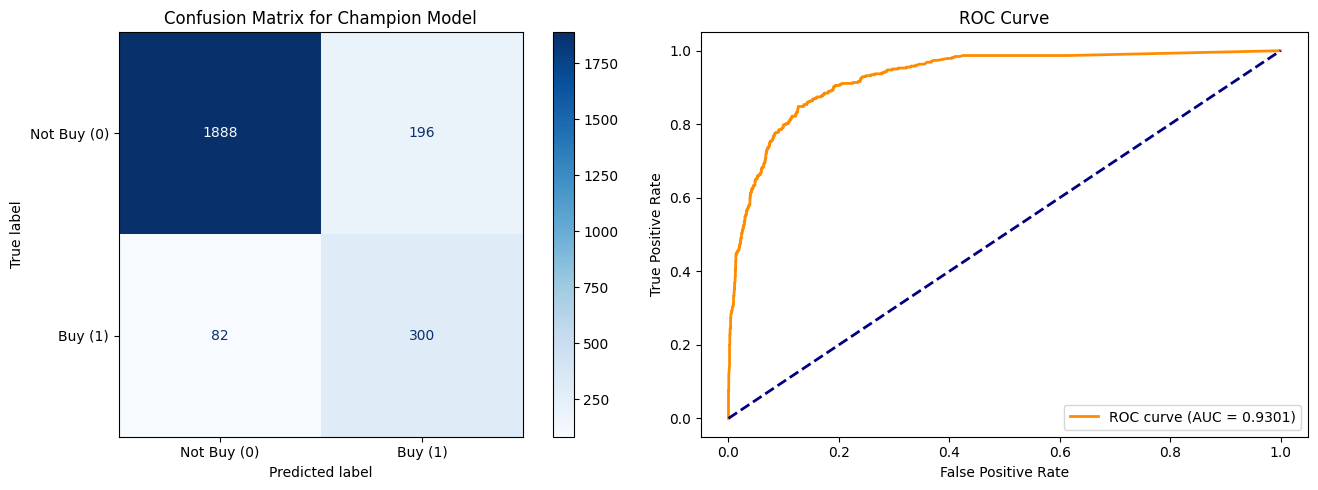

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Not Buy (0)', 'Buy (1)'], 
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix for Champion Model')

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {final_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

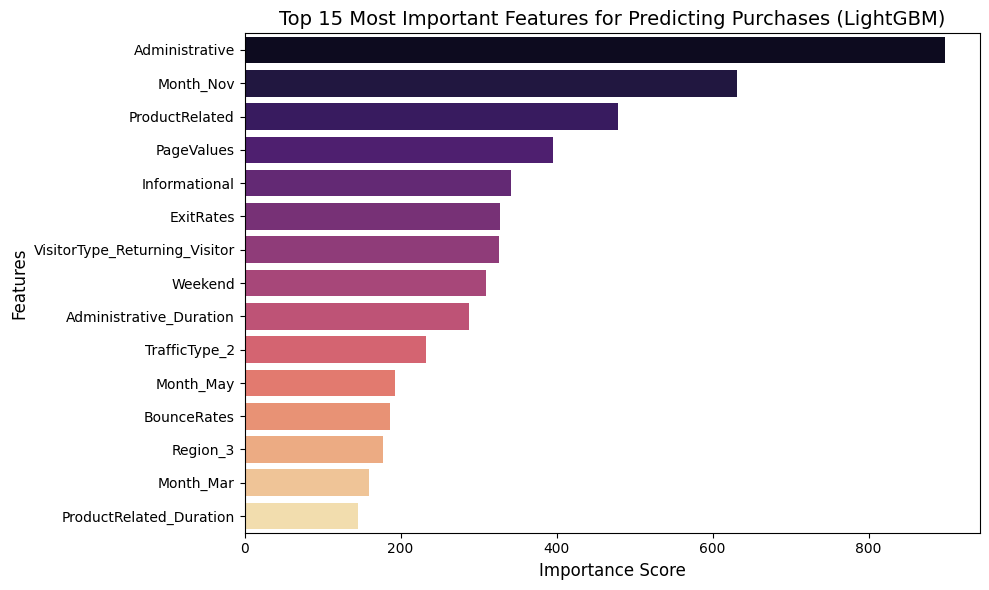

In [111]:
feature_names =X_train.columns
importances = final_pipeline.named_steps['model'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='magma')
plt.title('Top 15 Most Important Features for Predicting Purchases (LightGBM)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

### **Model Deployment**

In [95]:
import joblib

In [113]:
file_name = '../models/model.joblib'
joblib.dump(final_pipeline, file_name)
print(f"Final model saved as {file_name}")

Final model saved as ../models/model.joblib


In [114]:
column_names = list(X.columns)
joblib.dump(column_names, '../models/column_names.joblib')
print("Column names saved for future reference.")

Column names saved for future reference.
